In [1]:
import os
from pathlib import Path
from typing import List
import argparse
import sys

from torchtyping import TensorType as TT

from pff import config_dir, data_dir, reports_dir
from pff.config_classes.node_pk_config import NodePKConfig
from pff.data_empirical import (
    load_empirical_json_batches,
    load_empirical_hf_batches_as_dm,
    prediction_to_study_jsons,
)
from pff.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    AICMECompartmentsDataModule,
)
from pff.models.amortized_inference.aicme import AICMEPK
from pff.data_empirical.json_schema import StudyJSON
from pff.utils.plots.databatch_plot import (
    plot_list_list_study_json,
    plot_list_aicme_databatch,
    plot_study_json
)
from pff.data_empirical.builder import databatch_to_study_jsons
from pff.training.basic_experiment import BasicLightningExperiment

# "3320010e2df948a184f4480a7df9d8a0"

# READ EXPERIMENT

In [2]:
EXPERIMENT_KEY = "3320010e2df948a184f4480a7df9d8a0"
experiment = BasicLightningExperiment(experiment_key=EXPERIMENT_KEY)

CometLogger will be initialized in online mode
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/cesarali/aicmepk/3320010e2df948a184f4480a7df9d8a0

CometLogger will be initialized in online mode
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : elegant_marmoset_1769
COMET INFO:   

# SAMPLE AND STUFF

In [4]:
dm = experiment.datamodule
model = experiment.model
dm.prepare_data()
dm.setup()
model.eval()
loader = dm.train_dataloader()

synthetic_batch_list: List[AICMECompartmentsDataBatch] = next(iter(loader))
synthetic_batch = synthetic_batch_list[0]

## New Individual Sample

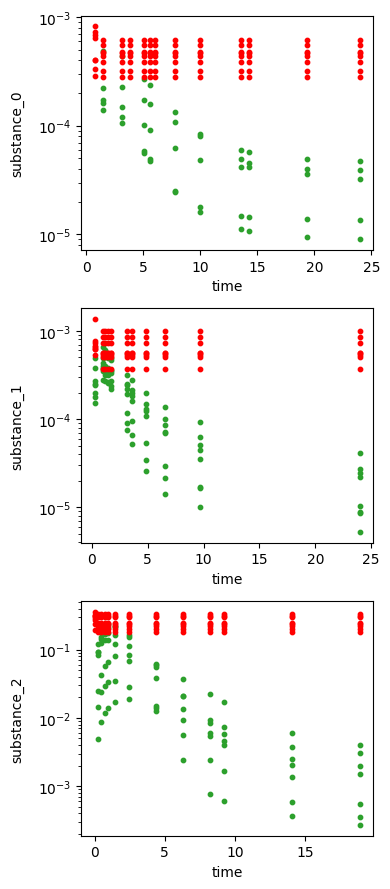

In [5]:
sampled_studies = model.sample_new_individuals_to_studyjson(
    synthetic_batch
)
plot_list_list_study_json([sampled_studies])

# Send to HF

In [11]:
from huggingface_hub import login, create_repo, HfApi

from pff import HUGGINGFACE_KEY
user = HfApi().whoami(token=HUGGINGFACE_KEY)["name"]
hf_repo_id = f"{user}/{"AICMEManual"}"

In [12]:
hf_repo_id

'cesarali/AICMEManual'

In [14]:
create_repo(hf_repo_id, exist_ok=True, token=HUGGINGFACE_KEY)

experiment._push_model_to_hub(
    model=experiment.model,
    hf_repo_id=hf_repo_id,
    commit_message=f"test manual upload to HF",
    alias_name="local training test",
)

Uploading...:   0%|          | 0.00/43.0M [00:00<?, ?B/s]